

## Lab 2

Welcome to the second lab of the AIML!
In addition to implementing code, there will be questions that you must answer which relate to the lab and your implementation. Each question you will answer is preceded by a **'Question X'** header. Carefully read each question and provide you answer or code in the following textboxes with **'Answer:'** header. Your lab submission will be evaluated based on your answers to each of the questions and the implementation you provide.

# Every question is of 1 mark.

## Overview

This module covers,

1) One sample and Two sample t-tests

2) ANOVA

3) Type I and Type II errors

4) Probabilty Distributions

5) Linear Regression

## Hypothesis Testing

The purpose of the test is to tell if there is any significant difference between two data sets.



## Question 1 

*A student is trying to decide between two GPUs. He want to use the GPU for his research to run Deep learning algorithms, so the only thing he is concerned with is speed.*

*He picks a Deep Learning algorithm on a large data set and runs it on both GPUs 15 times, timing each run in hours. Results are given in the below lists GPU1 and GPU2.*

Hint: You can import ttest function from scipy to perform t tests 

Given,

Null Hypothesis : There is no significant difference between data sets

Alternate Hypothesis : There is a significant difference

*Do two-sample testing and check whether to reject Null Hypothesis or not.*

#### Answer:

In [106]:
import pandas as pd
GPU1 = pd.DataFrame([11,9,10,11,10,12,9,11,12,9,11,12,9,10,9])
GPU2 = pd.DataFrame([11,13,10,13,12,9,11,12,12,11,12,12,10,11,13])

In [107]:
import numpy as np
from scipy.stats import ttest_1samp, ttest_ind, mannwhitneyu, levene, shapiro
from statsmodels.stats.power import ttest_power

In [108]:
t_statistic, p_value = ttest_ind(GPU1,GPU2)
print(t_statistic, p_value)

[-2.62762951] [0.01379428]


In [109]:
#accepting the null-hypothesis

[## Question 2 
](https://)
He is trying a third GPU which is GPU3.

In [110]:
GPU3 = pd.DataFrame([9,10,9,11,10,13,12,9,12,12,13,12,13,10,11])

#Assumption: Both the datasets (GPU1 & GPU 3) are random, independent, parametric & normally distributed

*Do two-sample testing and check whether there is significant differene between speeds of two GPUs GPU1 and GPU3.*

#### Answer:

In [111]:
# For checking equality of variance between groups
# Null Hypothesis: Variances are equal
levene(GPU1,GPU3)

LeveneResult(statistic=array([1.15463918]), pvalue=array([0.29175311]))

In [112]:
#p value > 0.05 means that there are no significant differences between GPU1 and GPU3

### ANOVA

## Question 3 

If you need to compare more than two data sets at a time, an ANOVA is your best bet. 

*The results from three experiments with overlapping 95% confidence intervals are given below, and we want to confirm that the results for all three experiments are not significantly different.*

#Assumption: All the 3 datasets (e1,e2 & e3) are random, independent, parametric & normally distributed
But before conducting ANOVA, test equality of variances (using Levene's test) is satisfied or not. If not, then mention that we cannot depend on the result of ANOVA

In [113]:
import pandas as pd
e1 = pd.DataFrame([1.595440,1.419730,0.000000,0.000000])
e2 = pd.DataFrame([1.433800,2.079700,0.892139,2.384740])
e3 = pd.DataFrame([0.036930,0.938018,0.995956,1.006970])

Hint - You can use stats.levene function and stats.f_oneway function.

#### Answer:

In [114]:
from scipy.stats import levene, shapiro, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [115]:
# For checking equality of variance between groups
# Null Hypothesis: Variances are equal
levene(e1,e2,e3)

LeveneResult(statistic=array([2.67417257]), pvalue=array([0.12259793]))

In [116]:
#p value > 0.05 means that there are no significant differences between e1,e2 & e3

In [117]:
f_oneway (e1,e2,e3)

F_onewayResult(statistic=array([2.51357623]), pvalue=array([0.13574645]))

In [118]:
# Since p value > 0.05, no significant difference exists between e1,e2 and e3

## Question 4 

*In one or two sentences explain about **TypeI** and **TypeII** errors.*

#### Answer:

# A type I error occurs if you reject the null hypothesis, H0, when it is true and should not be rejected. 

# A type I error is a "false alarm". The probability of a Type I error occuring is α


# A type II error occurs if you do not reject the null hypothesis, H0, when it is false and should not be rejected.

# A type II error repesents a "missed opportunity" to take some correction action. The probability of a Type II error occuring is β

# Question 5
You are a manager of a chinese restaurant. You want to determine whether the waiting time to place an order has changed in the past month from its previous population mean value of 4.5 minutes. 
State the null and alternative hypothesis.

# Null Hypothesis : Waiting time in the restaurant is 4.5 minutes
# Alternate Hypothesis :# Not Null hypothesis. Waiting time is not 4.5 minutes.

# Question 6 
Get the binomial distribution with n = 10, p = .7 and k = [0, 1, 2, 3, 4, 5, 6, 7]

Hint - Use stats.binom.pmf() function for this.


In [119]:
from scipy.stats import binom
n = 10
p = 0.7
k = [0,1,2,3,4,5,6,7]
binom.pmf (k,n,p)

array([5.90490000e-06, 1.37781000e-04, 1.44670050e-03, 9.00169200e-03,
       3.67569090e-02, 1.02919345e-01, 2.00120949e-01, 2.66827932e-01])

# Question 7 
Plot the distribution created in the above question.

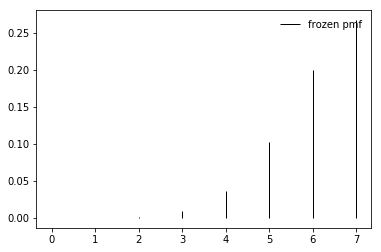

In [120]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
rv = binom(n, p)
ax.vlines(k, 0, rv.pmf(k), colors='k', linestyles='-', lw=1, label='frozen pmf')
ax.legend(loc='best', frameon=False)
plt.show()

# Linear Regression


# Simple Linear Regression

Here we will try to see that if we can make a regression model to predict one column of a dataset by the use of other coloumn.

## Dataset

Population of U.S. Cities

### Description
The bigcity data frame has 49 rows and 2 columns.

The measurements are the population (in 1000's) of 49 U.S. cities in 1920 and 1930. The 49 cities are a random sample taken from the 196 largest cities in 1920.

### Format
This data frame contains the following columns:

`u`
The 1920 population.

`x`
The 1930 population.

There is one unnamed column also in this dataset. Please remove and ignore that coloumn.

Source

The data were obtained from

Cochran, W.G. (1977) Sampling Techniques. Third edition. John Wiley

References

Davison, A.C. and Hinkley, D.V. (1997) Bootstrap Methods and Their Application. Cambridge University Press.

# Question 8 
Read the dataset given in file named 'bigcity.csv'.

In [121]:
bigcity = pd.read_csv("bigcity.csv")
bigcity.head()

,Unnamed: 0,u,x
0,1,138,143
1,2,93,104
2,3,61,69
3,4,179,260
4,5,48,75


# Question 9 - Transform the dataset 
Find the number of rows in given dataset and separate the input(u column)  and target variables(x column) into X and Y.

Remove the unnamed coloumn.

Hint: You can shape function to get the size of the dataframe


In [122]:
bigcity.shape

(49, 3)

In [123]:
bigcity.drop(bigcity.columns[bigcity.columns.str.contains('unnamed',case = False)],axis = 1,inplace=True)
bigcity.head()

,u,x
0,138,143
1,93,104
2,61,69
3,179,260
4,48,75


In [130]:
X = bigcity["u"]
Y = bigcity["x"]
print ("the value of X is",X)
print ("the value of Y is",Y)
print ("the number of rows in the dataframe is",bigcity.shape[0])

the value of X is 0     138
1      93
2      61
3     179
4      48
5      37
6      29
7      23
8      30
9       2
10     38
11     46
12     71
13     25
14    298
15     74
16     50
17     76
18    381
19    387
20     78
21     60
22    507
23     50
24     77
25     64
26     40
27    136
28    243
29    256
30     94
31     36
32     45
33     67
34    120
35    172
36     66
37     46
38    121
39     44
40     64
41     56
42     40
43    116
44     87
45     43
46     43
47    161
48     36
Name: u, dtype: int64
the value of Y is 0     143
1     104
2      69
3     260
4      75
5      63
6      50
7      48
8     111
9      50
10     52
11     53
12     79
13     57
14    317
15     93
16     58
17     80
18    464
19    459
20    106
21     57
22    634
23     64
24     89
25     77
26     60
27    139
28    291
29    288
30     85
31     46
32     53
33     67
34    115
35    183
36     86
37     65
38    113
39     58
40     63
41    142
42     64
43    130
44    105
45

## Question 10 - Check the dataset for any missing values and also print out the correlation matrix 

In [124]:
bigcity.isna()

,u,x
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,False


You can use .isna() and .corr() functions to check NA's and correlation in the dataframe respectively

# Since boolean values are False. There are no missing values in both columns

In [125]:
# Correlation
bigcity.corr()

,u,x
u,1.000000,0.981742
x,0.981742,1.000000


# Both u and x are highly correlated, hence can be used for predicting each other

### The high correlation betwwen u and x indicates that the variable u is a good predictor of variable x

# Question 11 - Split data into train, test sets 
Divide the data into training and test sets with 80-20 split using scikit-learn. Print the shapes of training and test feature sets.*

Check: train_test_split function

In [126]:
from sklearn.model_selection import train_test_split
# 20 pc data considered as test set
#trainingset, testset = train_test_split(bigcity,test_size=0.2)
#printing training set
#trainingset

In [127]:
#printing test set
#testset

In [128]:
#print("trainingset")
#print (trainingset.shape)
#print("testset")
#print (testset.shape)

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X,Y , test_size=0.2, random_state=0)
print("The y train data is",y_train.shape[0])
print("The x train shape is",X_train.shape[0])
print("The y test data is",y_test.shape[0])
print("The x test data is",X_test.shape[0])

The y train data is 39
The x train shape is 39
The y test data is 10
The x test data is 10


# Question 12 - Find coefficients & intercept
Estimate the coefficients b0 and b1 using scikit-learn.

In [136]:
from sklearn import linear_model
X = X_train.values.reshape(-1,1)
y = y_train.values.reshape(-1,1)
lreg = linear_model.LinearRegression()
reg = lreg.fit(X, y)
print("The Training data b1 value is",reg.coef_)

The Training data b1 value is [[1.16465537]]


In [137]:
print("The Training data b0 value is",reg.intercept_)

The Training data b0 value is [9.57115437]


Check: coef_ and intercept_ functions can help you get coefficients & intercept

# Question 13 - Linear Relationship between feature and target 
Plot the line with b1 and b0 as slope and y-intercept.

Hint - y = mx + c, plot y

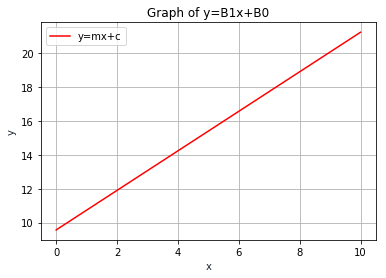

In [138]:
import matplotlib.pyplot as plt
from matplotlib import pylab
x = np.linspace(0,10,100)
y = 1.16465537*x+9.57115437
plt.plot(x, y, '-r', label='y=mx+c')
plt.title('Graph of y=B1x+B0')
plt.xlabel('x', color='#1C2833')
plt.ylabel('y', color='#1C2833')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Question 14 - Evaluation of model with scikit-learn 
Validate the model with Root Mean Squares error and R^2 score using scikit-learn. RMSE and R2 for test data and prediction

Hint: You can import mean_squared_error function & r2 (R square) from sklearn.metrics. Performing root operation over mean square error over mean square error gives you root mean square error

In [ ]:
#y_pred = lm.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

mse = mean_squared_error(Y_test, y_pred)

rmse = sqrt(mse)

In [140]:
y_pred = reg.predict(X_test.values.reshape(-1,1))

from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
R2Val = r2_score(y_test,y_pred)
print("The R2 value is",R2Val)
print("The rmse value is",rmse)


The R2 value is 0.92536721776934
The rmse value is 18.710703893730713


## Question 15 - Calculate the accuracy of the model for both training and test data set 

### Hint: .score() function 

In [142]:
scoreVal = lreg.score(X_test.values.reshape(-1,1), y_test.values.reshape(-1,1))
print("The score value is",scoreVal*100)


The score value is 92.536721776934
